In [1]:
import pandas as pd
from pathlib import Path

# Read a CSV file into a DataFrame and return None if loading fails.
def read_csv_to_dataframe(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as exc:
        print(f"An error occurred while reading {file_path}: {exc}")
        return None

In [2]:
import sys

project_root = Path(r'C:\Users\Divyeh\OneDrive\Desktop\ML_IP\NOVA_Food_Processing')
code_files_path = project_root / 'Code_Files'

for path in (project_root, code_files_path):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

data_path = project_root / 'Data' / 'Numerical' / 'Data' / '65_Nutrients_Data.csv'
data = read_csv_to_dataframe(data_path)

path_smote = project_root / 'models' / 'numerical_65_gb' / 'smote'
path_strat = project_root / 'models' / 'numerical_65_gb' / 'strat'
path_smote_strat = project_root / 'models' / 'numerical_65_gb' / 'smote_strat'
path_smote.mkdir(parents=True, exist_ok=True)
path_strat.mkdir(parents=True, exist_ok=True)
path_smote_strat.mkdir(parents=True, exist_ok=True)

print('Data and output folders are ready.')

Data and output folders are ready.


In [3]:
from sklearn.model_selection import train_test_split

# Split into features and target. The last column is the NOVA class label.
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (2376, 65), Test size: (594, 65)


In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from Utility_Codes.Utility_model_training import (
    evaluate_classifier_with_stratified_smote,
    evaluate_classifier_with_stratified_kfold,
    evaluate_classifier_with_kfold_smote,
)

# Create the Gradient Boosting model.
gb = GradientBoostingClassifier(random_state=42)

# Run the three evaluation strategies and save outputs/models.
evaluate_classifier_with_stratified_smote(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_smote_strat),
    model_name='gb_numerical_65_smote_stratified'
)
evaluate_classifier_with_stratified_kfold(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_strat),
    model_name='gb_numerical_65_stratified'
)
evaluate_classifier_with_kfold_smote(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_smote),
    model_name='gb_numerical_65_smote'
)

Average Accuracy Val K-Fold: 88.8460
Average Accuracy Train K-Fold: 98.2064
Average MCC Val K-Fold: 0.7737
Average MCC Train K-Fold: 0.9761
Average F1 Score Val K-Fold: 0.8922
Average F1 Score Train K-Fold: 0.9820
Average Precision Val K-Fold: 0.9022
Average Precision Train K-Fold: 0.9821
Average Recall Val K-Fold: 0.8885
Average Recall Train K-Fold: 0.9821
Accuracy Test: 88.55%
MCC Test: 0.7612
F1 Score Test: 0.8884
Precision Test: 0.8931
Recall Test: 0.8855
Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.84      0.79        68
           2       0.75      0.82      0.78        11
           3       0.71      0.77      0.74        93
           4       0.96      0.92      0.94       422

    accuracy                           0.89       594
   macro avg       0.79      0.84      0.81       594
weighted avg       0.89      0.89      0.89       594

Confusion Matrix Test:
[[ 57   0   8   3]
 [  0   9   0   2]
 [ 11   0  72  10

{'train_scores': [0.9805003679175864,
  0.9808550185873606,
  0.9799779573842763,
  0.9827332843497428,
  0.9803223388305847],
 'val_scores': [0.9054621848739496,
  0.888421052631579,
  0.8610526315789474,
  0.888421052631579,
  0.88]}

Average Accuracy Val K-Fold: 88.8460
Average Accuracy Train K-Fold: 98.2064
Average MCC Val K-Fold: 0.7737
Average MCC Train K-Fold: 0.9761
Average F1 Score Val K-Fold: 0.8922
Average F1 Score Train K-Fold: 0.9820
Average Precision Val K-Fold: 0.9022
Average Precision Train K-Fold: 0.9821
Average Recall Val K-Fold: 0.8885
Average Recall Train K-Fold: 0.9821
Accuracy Test: 88.55%
MCC Test: 0.7612
F1 Score Test: 0.8884
Precision Test: 0.8931
Recall Test: 0.8855
Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.84      0.79        68
           2       0.75      0.82      0.78        11
           3       0.71      0.77      0.74        93
           4       0.96      0.92      0.94       422

    accuracy                           0.89       594
   macro avg       0.79      0.84      0.81       594
weighted avg       0.89      0.89      0.89       594

Confusion Matrix Test:
[[ 57   0   8   3]
 [  0   9   0   2]
 [ 11   0  72  10

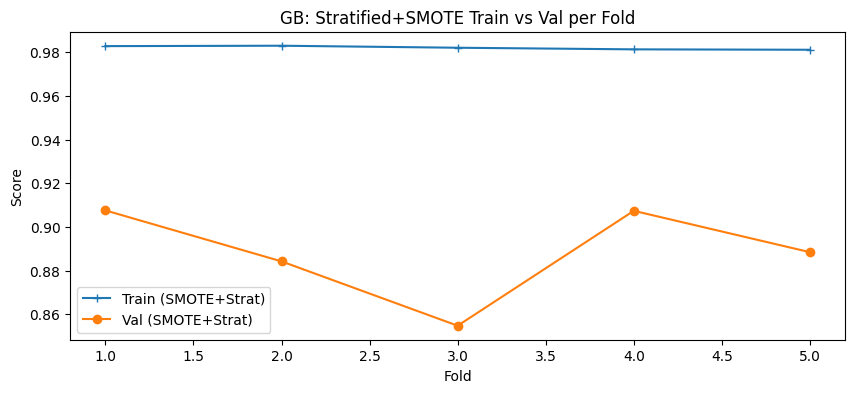

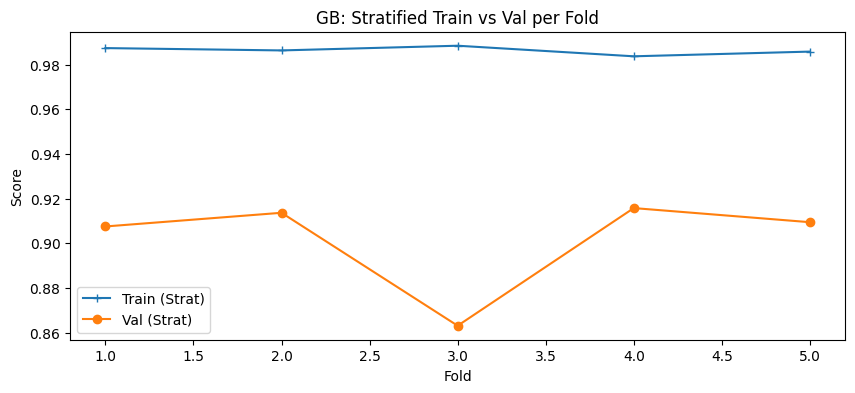

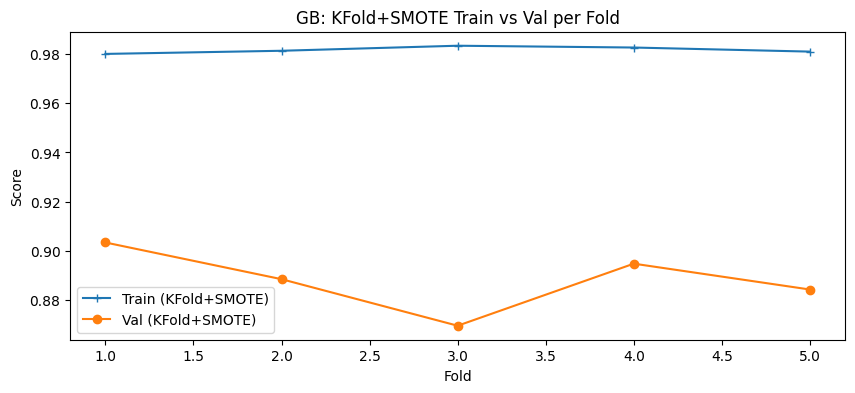

In [5]:
# Explicitly run evaluation but capture fold scores without plotting inside the utility
from Utility_Codes.Utility_model_training import (
    evaluate_classifier_with_stratified_smote,
    evaluate_classifier_with_stratified_kfold,
    evaluate_classifier_with_kfold_smote,
)

scores_smote_strat = evaluate_classifier_with_stratified_smote(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_smote_strat),
    model_name='gb_numerical_65_smote_stratified', plot_scores=False
)
scores_strat = evaluate_classifier_with_stratified_kfold(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_strat),
    model_name='gb_numerical_65_stratified', plot_scores=False
)
scores_smote = evaluate_classifier_with_kfold_smote(
    X_train, y_train, X_test, y_test, gb,
    num_folds=5, save_path=str(path_smote),
    model_name='gb_numerical_65_smote', plot_scores=False
)

# Plot the fold-wise train/validation curves inline for quick inspection
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_smote_strat['train_scores']) + 1), scores_smote_strat['train_scores'], label='Train (SMOTE+Strat)', marker='+')
plt.plot(range(1, len(scores_smote_strat['val_scores']) + 1), scores_smote_strat['val_scores'], label='Val (SMOTE+Strat)', marker='o')
plt.title('GB: Stratified+SMOTE Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_strat['train_scores']) + 1), scores_strat['train_scores'], label='Train (Strat)', marker='+')
plt.plot(range(1, len(scores_strat['val_scores']) + 1), scores_strat['val_scores'], label='Val (Strat)', marker='o')
plt.title('GB: Stratified Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(scores_smote['train_scores']) + 1), scores_smote['train_scores'], label='Train (KFold+SMOTE)', marker='+')
plt.plot(range(1, len(scores_smote['val_scores']) + 1), scores_smote['val_scores'], label='Val (KFold+SMOTE)', marker='o')
plt.title('GB: KFold+SMOTE Train vs Val per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.show()

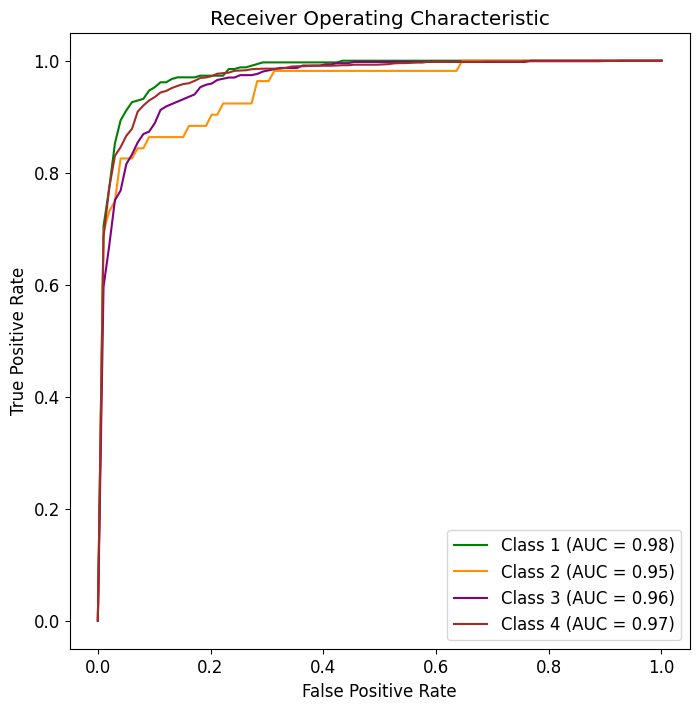

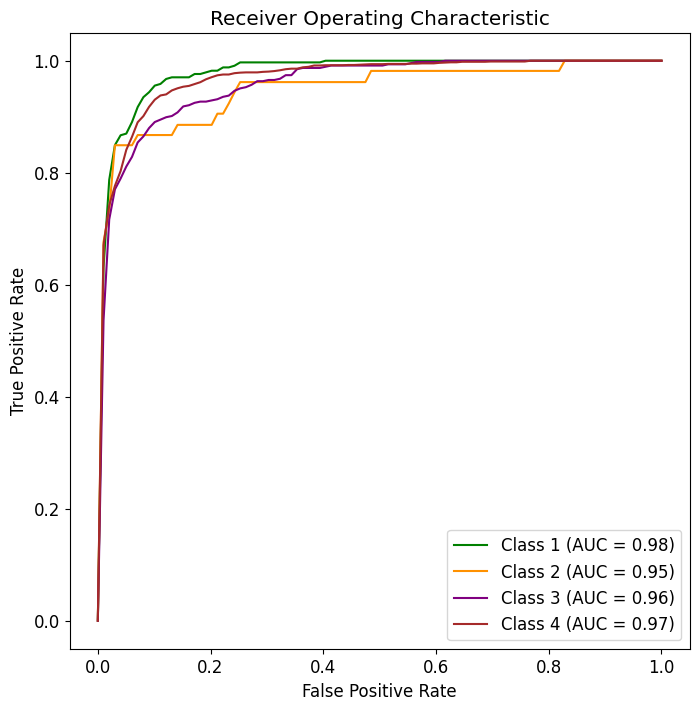

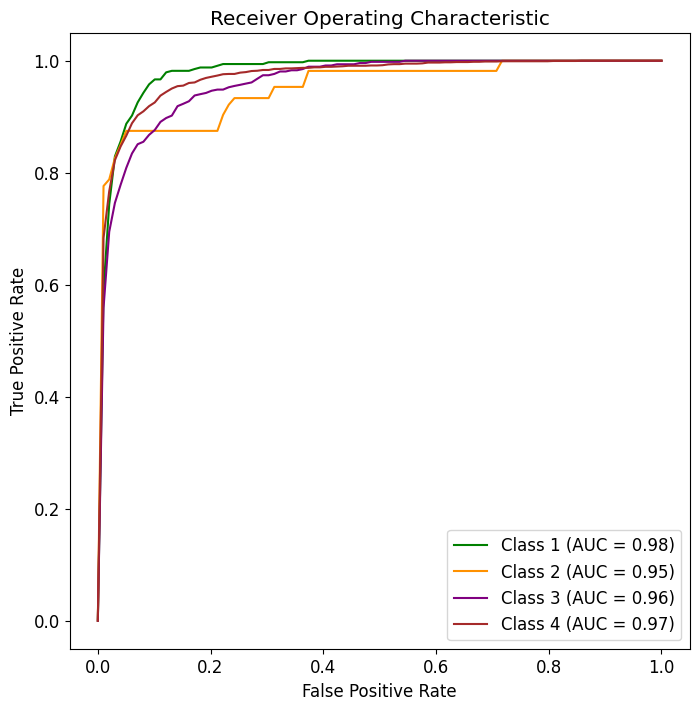

In [3]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier

from Utility_ROC_Curves import (
    plot_roc_curves_multiclass_smote_strat,
    plot_roc_curves_multiclass_strat,
    plot_roc_curves_multiclass_smote,
)

if 'project_root' not in globals():
    cwd = Path.cwd().resolve()
    if (cwd / 'models').exists():
        project_root = cwd
    elif (cwd.parent / 'models').exists():
        project_root = cwd.parent
    else:
        project_root = cwd

if 'X' not in globals() or 'y' not in globals():
    data_path = project_root / 'Data' / 'Numerical' / 'Data' / '65_Nutrients_Data.csv'
    data = pd.read_csv(data_path)
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

if 'gb' not in globals():
    gb = GradientBoostingClassifier(random_state=42)

path_strat_ROC = project_root / 'models' / 'numerical_65_gb' / 'strat' / 'ROC_Curves'
path_smote_strat_ROC = project_root / 'models' / 'numerical_65_gb' / 'smote_strat' / 'ROC_Curves'
path_smote_ROC = project_root / 'models' / 'numerical_65_gb' / 'smote' / 'ROC_Curves'

# 1. Stratified baseline
plot_roc_curves_multiclass_strat(
    gb, X, y, n_splits=5, save_folder=str(path_strat_ROC),
    model_name='gb_numerical_65_stratified'
)
# 2. Stratified + SMOTE
plot_roc_curves_multiclass_smote_strat(
    gb, X, y, n_splits=5, save_folder=str(path_smote_strat_ROC),
    model_name='gb_numerical_65_smote_stratified'
)
# 3. KFold + SMOTE
plot_roc_curves_multiclass_smote(
    gb, X, y, n_splits=5, save_folder=str(path_smote_ROC),
    model_name='gb_numerical_65_smote'
)

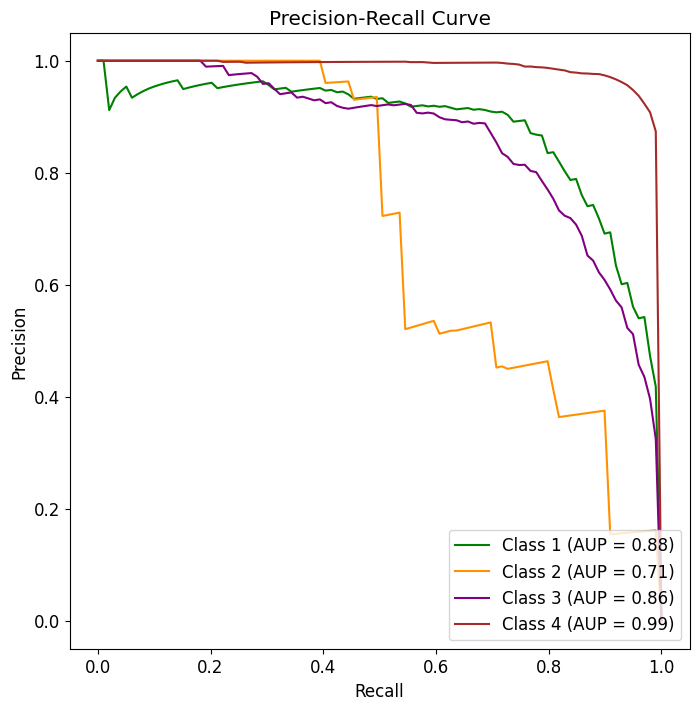

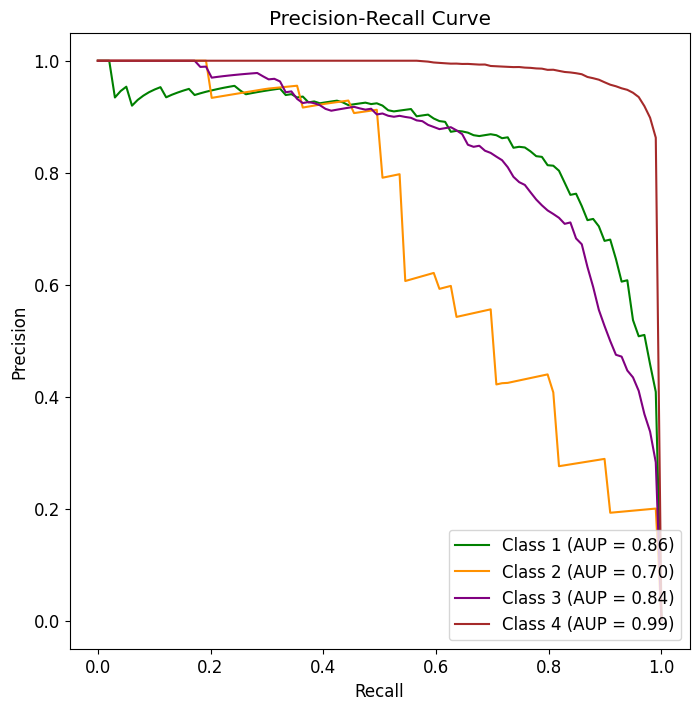

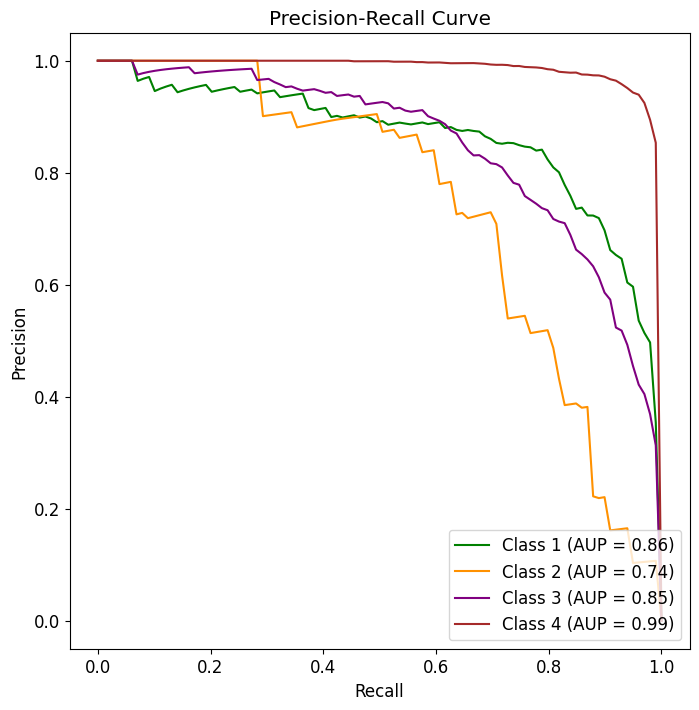

In [4]:
from Utility_AUPRC import (
    plot_pr_curves_multiclass_strat,
    plot_pr_curves_multiclass_strat_smote,
    plot_pr_curves_multiclass_kfold_smote,
)

path_strat_PR = project_root / 'models' / 'numerical_65_gb' / 'strat' / 'PR_Curves'
path_smote_strat_PR = project_root / 'models' / 'numerical_65_gb' / 'smote_strat' / 'PR_Curves'
path_smote_PR = project_root / 'models' / 'numerical_65_gb' / 'smote' / 'PR_Curves'

# 1. Stratified baseline
plot_pr_curves_multiclass_strat(
    gb, X, y, n_splits=5, save_folder=str(path_strat_PR),
    model_name='gb_numerical_65_stratified'
)
# 2. Stratified + SMOTE
plot_pr_curves_multiclass_strat_smote(
    gb, X, y, n_splits=5, save_folder=str(path_smote_strat_PR),
    model_name='gb_numerical_65_smote_stratified'
)
# 3. KFold + SMOTE
plot_pr_curves_multiclass_kfold_smote(
    gb, X, y, n_splits=5, save_folder=str(path_smote_PR),
    model_name='gb_numerical_65_smote'
)